# Convolución Transpuesta

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Convolución directa como operador lineal

La convolución 1D con kernel $w=(w_1,\ldots,w_K)$, stride $S=1$ y padding $P=0$ es equivalente a la multiplicación matricial $y = Ax$, donde $A$ es una matriz de Toeplitz:

In [2]:
def build_toeplitz(w, D_in, S=1, P=0):
    K = len(w)
    D_out = (D_in + 2 * P - K) // S + 1
    A = torch.zeros(D_out, D_in)
    for j in range(D_out):
        for k in range(K):
            col = j * S + k - P
            if 0 <= col < D_in:
                A[j, col] = w[k]
    return A

In [3]:
# Ejemplo:
w = torch.tensor([1.0, 2.0, 3.0])
D_in = 7
A = build_toeplitz(w, D_in)

print(f"Dimensión de salida: {A.shape[0]}")
print("\nMatriz de Toeplitz asociada:")
print(A.numpy())

Dimensión de salida: 5

Matriz de Toeplitz asociada:
[[1. 2. 3. 0. 0. 0. 0.]
 [0. 1. 2. 3. 0. 0. 0.]
 [0. 0. 1. 2. 3. 0. 0.]
 [0. 0. 0. 1. 2. 3. 0.]
 [0. 0. 0. 0. 1. 2. 3.]]


Se puede comparar con la implementación de PyTorch:

In [4]:
x = torch.randn(D_in)
y_matrix = A @ x

conv = nn.Conv1d(1, 1, kernel_size=3, stride=1, padding=0, bias=False)
conv.weight.data[0, 0] = w
y_conv = conv(x.view(1, -1)).squeeze()

assert torch.allclose(y_matrix, y_conv), "Los resultados no coinciden"

## Checkerboard artifacts

En una convolución transpuesta, cuando $K$ no es múltiplo de $S$, se produce un patrón de cuadrículas:

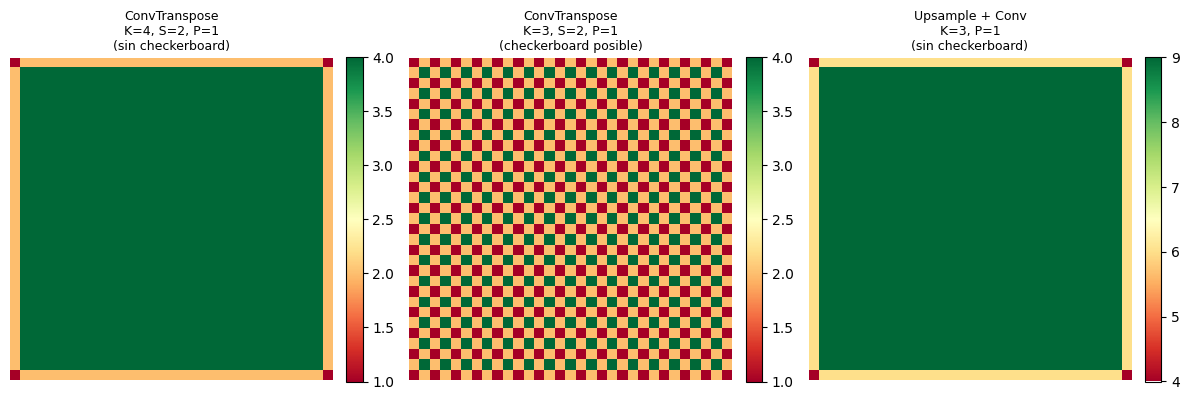

In [5]:
def make_upsampled_constant(K, S, P, mode='conv_transpose'):
    """Genera un feature map constante y lo pasa por un bloque de upsampling."""
    in_ch, out_ch, H, W = 1, 1, 16, 16
    x = torch.ones(1, in_ch, H, W)

    if mode == 'conv_transpose':
        layer = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=K, stride=S, padding=P, bias=False)
        nn.init.constant_(layer.weight, 1.0)
    else:  # upsample + conv
        layer = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_ch, out_ch, kernel_size=K, padding=K//2, bias=False),
        )
        nn.init.constant_(layer[1].weight, 1.0)

    with torch.no_grad():
        y = layer(x)
    return y.squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
configs_img = [
    (4, 2, 1, 'conv_transpose', 'ConvTranspose\nK=4, S=2, P=1\n(sin checkerboard)'),
    (3, 2, 1, 'conv_transpose', 'ConvTranspose\nK=3, S=2, P=1\n(checkerboard posible)'),
    (3, 2, 1, 'upsample',      'Upsample + Conv\nK=3, P=1\n(sin checkerboard)'),
]

for ax, (K, S, P, mode, title) in zip(axes, configs_img):
    out = make_upsampled_constant(K, S, P, mode)
    im = ax.imshow(out, cmap='RdYlGn', vmin=out.min(), vmax=out.max())
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()